# Gemma Model Experiments for Text-to-SQL (Spider Dataset)

Purpose:
This file contains the implementation used to evaluate and fine-tune Gemma models
for the text-to-SQL task on the Spider benchmark. The script includes code for
running zero-shot inference with Gemma-1 2B IT, performing parameter-efficient
fine-tuning using LoRA (PEFT), and evaluating a larger model (Gemma-3 4B IT).

Contents:
1. Data loading and preprocessing for the Spider dataset
2. Schema formatting and prompt construction for text-to-SQL generation
3. Zero-shot inference pipeline for Gemma-1 2B IT
4. LoRA-based parameter-efficient fine-tuning for Gemma-1 2B
5. Batched inference using the fine-tuned model
6. Zero-shot evaluation using Gemma-3 4B IT
7. Post-processing, execution-based evaluation, and error analysis of generated SQL queries

The outputs generated by this file are saved as JSON prediction files and are used
for computing execution accuracy and analyzing error distributions across models.

Written by Aditi Pattanshetti

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os

SPIDER_PATH = "/content/drive/MyDrive/175/spider_data"
os.listdir(SPIDER_PATH)

['train_gold.sql',
 'dev_gold.sql',
 'dev.json',
 'train_others.json',
 'train_spider.json',
 'tables.json',
 'README.txt',
 'test_tables.json',
 'test.json',
 'test_gold.sql',
 '.DS_Store',
 'database',
 'test_database']

In [3]:
!pip install -U transformers accelerate bitsandbytes datasets sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 196.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.5/527.5 kB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 68.2 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [4]:
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get('HF_TOKEN'))

In [ ]:
!nvidia-smi

Wed Feb 25 01:50:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          Off |   00000000:04:00.0 Off |                    0 |
| N/A   38C    P0             69W /  700W |       0MiB /  81559MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
# code for loading gemma2b to run on GPUs
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "google/gemma-2b-it"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map="auto",
    torch_dtype=torch.float16
)

model.eval()

config.json:   0%|          | 0.00/627 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/34.2k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/13.5k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

GemmaForCausalLM(
  (model): GemmaModel(
    (embed_tokens): Embedding(256000, 2048, padding_idx=0)
    (layers): ModuleList(
      (0-17): 18 x GemmaDecoderLayer(
        (self_attn): GemmaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=256, bias=False)
          (v_proj): Linear(in_features=2048, out_features=256, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): GemmaMLP(
          (gate_proj): Linear(in_features=2048, out_features=16384, bias=False)
          (up_proj): Linear(in_features=2048, out_features=16384, bias=False)
          (down_proj): Linear(in_features=16384, out_features=2048, bias=False)
          (act_fn): GELUActivation()
        )
        (input_layernorm): GemmaRMSNorm((2048,), eps=1e-06)
        (post_attention_layernorm): GemmaRMSNorm((2048,), eps=1e-06)
      )
    )
    (norm): GemmaRMSNorm((2048,), 

In [5]:
## testing for running a few spider examples
import json, os

# 1. load dev examples
with open(os.path.join(SPIDER_PATH, "dev.json")) as f:
    dev_data = json.load(f)

with open(os.path.join(SPIDER_PATH, "train_spider.json")) as f:
    train_data = json.load(f)

print(f"Loaded {len(dev_data)} dev examples")
print(f"Loaded {len(train_data)} train examples")

Loaded 1034 dev examples
Loaded 7000 train examples


In [6]:
# 2. load table schema
with open(os.path.join(SPIDER_PATH, "tables.json")) as f:
    tables = json.load(f)

# Function to get schema for a specific db_id
def get_schema(db_id):
    for t in tables:
        if t["db_id"] == db_id:
            return t
    return None

In [7]:
# 3. format schema for prompt
def format_schema(schema):
    table_names = schema["table_names_original"]
    column_names = schema["column_names_original"]

    # Map table_id → list of columns
    tables_dict = {i: [] for i in range(len(table_names))}

    for col_name, table_id in column_names:
        # Skip columns with table_id == "*" or invalid
        if table_id == "*" or table_id is None:
            continue
        try:
            table_id_int = int(table_id)
        except ValueError:
            continue
        if table_id_int >= 0:
            tables_dict[table_id_int].append(col_name)

    # Build schema string
    schema_str = ""
    for i, table in enumerate(table_names):
        cols = ", ".join(tables_dict[i])
        schema_str += f"Table {table} has columns: {cols}\n"

    return schema_str

In [8]:
# 4. build prompt
def build_prompt(example):
    schema = get_schema(example["db_id"])
    schema_text = format_schema(schema)

    prompt = f"""
      You are an expert data analyst.
      Given the database schema below, write **ONLY the SQL query** for the question.
      Do NOT include any explanations, answers, or additional text. Output only the SQL query.

      Schema:
      {schema_text}

      Question:
      {example['question']}

      SQL Query:
      """
    return prompt

In [ ]:
# # Updated loop for cleaner SQL output
# results = []

# for example in dev_data[:5]:  # Testing first 5 examples
#     prompt = build_prompt(example)

#     # 1. Explicitly tokenize and keep track of the input length
#     input_data = tokenizer(prompt, return_tensors="pt").to(model.device)
#     input_length = input_data['input_ids'].shape[1]

#     with torch.no_grad():
#         outputs = model.generate(
#             **input_data,
#             max_new_tokens=64,  # Reduced since SQL queries are usually short
#             do_sample=False,
#             # temperature=0.0 is implied when do_sample=False
#         )

#     # 2. Slice the output to exclude the prompt tokens
#     generated_tokens = outputs[0][input_length:]
#     raw_output = tokenizer.decode(generated_tokens, skip_special_tokens=True)

#     # 3. Post-processing: Extract only the SQL statement
#     # We split by ';' to stop at the end of the query in case the model keeps talking
#     predicted_sql = raw_output.replace("```sql", "").replace("```", "").strip()
#     predicted_sql = predicted_sql.split(';')[0].strip()
#     if predicted_sql:
#         predicted_sql += ";"

#     results.append({
#         "question": example["question"],
#         "db_id": example["db_id"],
#         "gold_sql": example["query"],
#         "predicted_sql": predicted_sql
#     })

#     print("\n--- Example ---")
#     print(f"Question: {example['question']}")
#     print(f"Gold SQL: {example['query']}")
#     print(f"Predicted SQL: {predicted_sql}")


--- Example ---
Question: How many singers do we have?
Gold SQL: SELECT count(*) FROM singer
Predicted SQL: SELECT COUNT(*) FROM singer;

--- Example ---
Question: What is the total number of singers?
Gold SQL: SELECT count(*) FROM singer
Predicted SQL: SELECT COUNT(*) AS total_number_of_singers
      FROM singer;

--- Example ---
Question: Show name, country, age for all singers ordered by age from the oldest to the youngest.
Gold SQL: SELECT name ,  country ,  age FROM singer ORDER BY age DESC
Predicted SQL: SELECT s.name, s.country, s.age
      FROM singer s
      ORDER BY s.age DESC;

--- Example ---
Question: What are the names, countries, and ages for every singer in descending order of age?
Gold SQL: SELECT name ,  country ,  age FROM singer ORDER BY age DESC
Predicted SQL: SELECT s.name, s.country, s.age
      FROM singer s
      ORDER BY s.age DESC;

--- Example ---
Question: What is the average, minimum, and maximum age of all singers from France?
Gold SQL: SELECT avg(age) ,

In [ ]:
# run on full dataset
# save output to json file in /175/outputs folder

import json
import os
from tqdm import tqdm

# Define the output path
OUTPUT_DIR = "/content/drive/MyDrive/175/outputs"
OUTPUT_FILE = os.path.join(OUTPUT_DIR, "gemma2bIT_output.json")

# Ensure the directory exists
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

results = []

print(f"Running inference on {len(dev_data)} examples...")

# Loop through the entire dataset with a progress bar
for example in tqdm(dev_data):
    prompt = build_prompt(example)

    # Explicitly tokenize and keep track of the input length
    input_data = tokenizer(prompt, return_tensors="pt").to(model.device)
    input_length = input_data['input_ids'].shape[1]

    with torch.no_grad():
        outputs = model.generate(
            **input_data,
            max_new_tokens=64,
            do_sample=False,
        )

    # Slice the output to exclude the prompt tokens
    generated_tokens = outputs[0][input_length:]
    raw_output = tokenizer.decode(generated_tokens, skip_special_tokens=True)

    # Post-processing: Extract only the SQL statement
    predicted_sql = raw_output.replace("```sql", "").replace("```", "").strip()
    predicted_sql = predicted_sql.split(';')[0].strip()
    if predicted_sql:
        predicted_sql += ";"

    results.append({
        "question": example["question"],
        "db_id": example["db_id"],
        "gold_sql": example["query"],
        "predicted_sql": predicted_sql
    })

# Save results to JSON
with open(OUTPUT_FILE, 'w') as f:
    json.dump(results, f, indent=4)

print(f"\nDone! Outputs saved to {OUTPUT_FILE}")

Running inference on 1034 examples...


100%|██████████| 1034/1034 [17:09<00:00,  1.00it/s]


Done! Outputs saved to /content/drive/MyDrive/175/outputs/gemma2bIT_output.json


In [ ]:
# using peft + lora to target specific errors - syntax, schema mismatch

# 1. Install additional PEFT libraries
!pip install -U trl peft bitsandbytes accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 540.5/540.5 kB 19.9 MB/s eta 0:00:00


In [ ]:
import os
def get_latest_checkpoint(folder):
    if not os.path.exists(folder):
        return None
    checkpoints = [
        os.path.join(folder, d)
        for d in os.listdir(folder)
        if d.startswith("checkpoint-")
    ]
    if not checkpoints:
        return None
    # Sort by checkpoint number
    checkpoints = sorted(checkpoints, key=lambda x: int(x.split("-")[-1]))
    return checkpoints[-1]

In [ ]:
%env PYTORCH_ALLOC_CONF=expandable_segments:True
import torch
import os
from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig
from datasets import Dataset

# 0.1 convert Spider JSON to HF dataset
clean_data = []

for ex in train_data:
    clean_data.append({
        "question": ex["question"],
        "db_id": ex["db_id"],
        "query": ex["query"]
    })
train_dataset = Dataset.from_list(clean_data)

# 0.2 check to see if there are checkpoints saved
local_dir = "/content/gemma-sql-lora"
output_dir = "/content/drive/MyDrive/175/gemma-sql-lora"

# Get latest checkpoint from both locations
latest_local = get_latest_checkpoint(local_dir)
latest_drive = get_latest_checkpoint(output_dir)

# Pick the newest one
if latest_local and latest_drive:
    # Compare checkpoint numbers
    local_num = int(latest_local.split("-")[-1])
    drive_num = int(latest_drive.split("-")[-1])
    last_checkpoint = latest_local if local_num > drive_num else latest_drive
elif latest_local:
    last_checkpoint = latest_local
elif latest_drive:
    last_checkpoint = latest_drive
else:
    last_checkpoint = None

if last_checkpoint:
    print(f"Resuming from checkpoint: {last_checkpoint}")
else:
    print("No checkpoint found, starting fresh training.")


# =========================
# 1. 4-bit quantization
# =========================
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    offload_folder="/content/drive/MyDrive/offload",
    torch_dtype=torch.float16
)

model = prepare_model_for_kbit_training(model)

# =========================
# 2. LoRA config
# =========================
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "q_proj","k_proj","v_proj","o_proj",
        "gate_proj","up_proj","down_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

# =========================
# 3. Formatting function
# =========================
def formatting_func(example):
    prompt = build_prompt(example)
    return prompt + example["query"]

# =========================
# 4. NEW TRL CONFIG (LATEST API)
# =========================
sft_config = SFTConfig(
    output_dir = output_dir,

    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,

    learning_rate=2e-4,
    max_steps=2750,

    logging_steps=20,
    save_steps=200,

    fp16=False,
    bf16=False,

    optim="paged_adamw_8bit",

    max_length=384,

    packing=False,
    report_to="none"
)

# =========================
# 5. Trainer
# =========================
trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    args=sft_config,
    peft_config=lora_config,
    formatting_func=formatting_func,
)

# =========================
# 6. Train
# =========================
print("Starting training...")
trainer.train(resume_from_checkpoint=last_checkpoint)

trainer.model.save_pretrained(output_dir)
tokenizer.save_pretrained(output_dir)

print("Done!")

env: PYTORCH_ALLOC_CONF=expandable_segments:True
No checkpoint found, starting fresh training.


Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

Applying formatting function to train dataset:   0%|          | 0/7000 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/7000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/7000 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/7000 [00:00<?, ? examples/s]

Starting training...


Step,Training Loss
20,1.028189
40,0.555809
60,0.471814
80,0.409512
100,0.371140
120,0.362263
140,0.347469
160,0.346858
180,0.343558
200,0.313197


Done!


In [ ]:
import torch
import json
import os
from tqdm import tqdm
import re

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)
from peft import PeftModel


# =========================
# PATHS
# =========================
SPIDER_PATH = "/content/drive/MyDrive/175/spider_data"
LORA_PATH = "/content/drive/MyDrive/175/gemma-sql-lora/checkpoint-2750"
OUTPUT_DIR = "/content/drive/MyDrive/175/outputs"
OUTPUT_FILE = os.path.join(OUTPUT_DIR, "gemma_lora_dev_predictions.json")

MODEL_NAME = "google/gemma-2b-it"

os.makedirs(OUTPUT_DIR, exist_ok=True)

def clean_sql(output):
    output = output.replace("```sql", "").replace("```", "")

    # Find first SELECT statement
    match = re.search(r"(SELECT .*?;)", output, re.IGNORECASE | re.DOTALL)

    if match:
        sql = match.group(1)
    else:
        # fallback: try without semicolon
        match = re.search(r"(SELECT .*?$)", output, re.IGNORECASE | re.DOTALL)
        sql = match.group(1) if match else ""

    # Remove schema garbage patterns
    sql = re.sub(r"\.\._db_schema.*", "", sql)
    sql = re.sub(r"\s+FROM\s+.*?_db_schema.*", "", sql)

    # Clean spacing
    sql = " ".join(sql.split())

    # Ensure single semicolon
    sql = sql.rstrip(";") + ";"

    return sql

# =========================
# LOAD DATA
# =========================
with open(f"{SPIDER_PATH}/dev.json") as f:
    dev_data = json.load(f)

print("Loaded", len(dev_data), "examples")


# =========================
# LOAD MODEL (FAST MODE)
# =========================
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(LORA_PATH)

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto"
)

model = PeftModel.from_pretrained(base_model, LORA_PATH)
model.eval()
model.config.use_cache = True

print("Model loaded.")


# =========================
# BATCH SETTINGS
# =========================
BATCH_SIZE = 16      # H100 can easily handle this
MAX_NEW_TOKENS = 40  # SQL never needs more


# =========================
# HELPER: batching
# =========================
def batchify(data, batch_size):
    for i in range(0, len(data), batch_size):
        yield data[i:i + batch_size]


# =========================
# RUN INFERENCE
# =========================
results = []

print("\nRunning FAST batch inference...")

for batch in tqdm(list(batchify(dev_data, BATCH_SIZE))):

    prompts = [build_prompt(ex) for ex in batch]

    inputs = tokenizer(
        prompts,
        padding=True,
        truncation=True,
        return_tensors="pt"
    ).to(model.device)

    input_lengths = inputs["attention_mask"].sum(dim=1)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
            use_cache=True
        )

    # Decode each example
    for i, ex in enumerate(batch):
        gen_tokens = outputs[i][input_lengths[i]:]
        raw_output = tokenizer.decode(gen_tokens, skip_special_tokens=True)
        predicted_sql = clean_sql(raw_output)

        # predicted_sql = raw_output.replace("```sql", "").replace("```", "").strip()
        # predicted_sql = predicted_sql.split(";")[0].strip()
        # if predicted_sql:
        #     predicted_sql += ";"

        results.append({
            "question": ex["question"],
            "db_id": ex["db_id"],
            "gold_sql": ex["query"],
            "predicted_sql": predicted_sql
        })


# =========================
# SAVE OUTPUT
# =========================
with open(OUTPUT_FILE, "w") as f:
    json.dump(results, f, indent=4)

print("\n✅ DONE!")
print("Saved to:", OUTPUT_FILE)

Loaded 1034 examples


Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

Model loaded.

Running FAST batch inference...


100%|██████████| 65/65 [01:47<00:00,  1.65s/it]


✅ DONE!
Saved to: /content/drive/MyDrive/175/outputs/gemma_lora_dev_predictions.json


In [24]:
# try running higher gemma model --> gemma 3 4B-it

# code for loading gemma2b to run on GPUs

import json
import os
from tqdm import tqdm
from transformers import pipeline

generator = pipeline(
    "text-generation",
    model="google/gemma-3-4b-it",
    tokenizer="google/gemma-3-4b-it",
    device=0,           # GPU device
    max_new_tokens=128,
    return_full_text=False
)


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

In [27]:
import logging
logging.getLogger("transformers").setLevel(logging.ERROR)

OUTPUT_DIR = "/content/drive/MyDrive/175/outputs"
OUTPUT_FILE = os.path.join(OUTPUT_DIR, "gemma3-4bIT_output.json")

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

# ----------------------------
# 3. Helper functions
# ----------------------------
# Get schema for a specific db_id
def get_schema(db_id):
    for t in tables:
        if t["db_id"] == db_id:
            return t
    return None

# Format schema for prompt
def format_schema(schema):
    table_names = schema["table_names_original"]
    column_names = schema["column_names_original"]

    tables_dict = {i: [] for i in range(len(table_names))}
    for col_name, table_id in column_names:
        if table_id == "*" or table_id is None:
            continue
        try:
            table_id_int = int(table_id)
        except ValueError:
            continue
        if table_id_int >= 0:
            tables_dict[table_id_int].append(col_name)

    schema_str = ""
    for i, table in enumerate(table_names):
        cols = ", ".join(tables_dict[i])
        schema_str += f"Table {table} has columns: {cols}\n"

    return schema_str

# Build the prompt
def build_prompt(example):
    schema = get_schema(example["db_id"])
    schema_text = format_schema(schema)

    prompt = f"""
You are an expert data analyst.
Given the database schema below, write ONLY the SQL query.
Do NOT include explanations or extra text.

Schema:
{schema_text}

Question:
{example['question']}

SQL Query:
"""
    return prompt

# ----------------------------
# 4. Run inference on 150 examples
# ----------------------------
results = []
subset = dev_data[:150]

print(f"Running inference on {len(subset)} examples...")

for example in tqdm(subset):
    prompt = build_prompt(example)

    # Generate with Gemma 3-4B pipeline
    raw_output = generator(prompt)[0]["generated_text"]

    # Extract SQL (take everything after the last 'SQL Query:' in the output)
    if "SQL Query:" in raw_output:
        predicted_sql = raw_output.split("SQL Query:")[-1].strip()
    else:
        predicted_sql = raw_output.strip()

    # Keep only first SQL statement, add semicolon if missing
    if "SELECT" in predicted_sql.upper():
        predicted_sql = predicted_sql[predicted_sql.upper().find("SELECT"):]
    predicted_sql = predicted_sql.split(";")[0].strip() + ";"

    results.append({
        "question": example["question"],
        "db_id": example["db_id"],
        "gold_sql": example["query"],
        "predicted_sql": predicted_sql
    })

# ----------------------------
# 5. Save results to JSON
# ----------------------------
with open(OUTPUT_FILE, 'w') as f:
    json.dump(results, f, indent=4)

print(f"\nDone! Outputs saved to {OUTPUT_FILE}")

Running inference on 150 examples...


100%|██████████| 150/150 [04:13<00:00,  1.69s/it]


Done! Outputs saved to /content/drive/MyDrive/175/outputs/gemma3-4bIT_output.json


In [28]:
import json
import re
import os

# Paths
INPUT_FILE = "/content/drive/MyDrive/175/outputs/gemma3-4bIT_output.json"
OUTPUT_FILE = "/content/drive/MyDrive/175/outputs/gemma3-4bIT_output_clean.json"

# Load JSON
with open(INPUT_FILE, 'r') as f:
    data = json.load(f)

# Clean predicted_sql
for entry in data:
    sql = entry.get("predicted_sql", "")

    # 1. Remove newlines
    sql = sql.replace("\n", " ")

    # 2. Collapse multiple spaces to a single space
    sql = re.sub(r"\s+", " ", sql)

    # 3. Strip leading/trailing spaces
    sql = sql.strip()

    # Update entry
    entry["predicted_sql"] = sql

# Save cleaned JSON
with open(OUTPUT_FILE, 'w') as f:
    json.dump(data, f, indent=4)

print(f"Cleaned JSON saved to {OUTPUT_FILE}")

Cleaned JSON saved to /content/drive/MyDrive/175/outputs/gemma3-4bIT_output_clean.json


In [6]:
import json
import sqlite3
from tqdm import tqdm

# Paths
BASE_PATH = "/content/drive/MyDrive/175/spider_data"
PRED_PATH = "/content/drive/MyDrive/175/outputs/gemma3-4bIT_output_clean.json"
# Load prediction file
with open(PRED_PATH) as f:
    predictions = json.load(f)

print("Loaded predictions:", len(predictions))


def execute_sql(db_id, sql):

    db_path = f"{BASE_PATH}/database/{db_id}/{db_id}.sqlite"

    try:
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()

        cursor.execute(sql)
        result = cursor.fetchall()

        conn.close()

        return result, None

    except Exception as e:
        return None, str(e)


correct = 0
total = 0
failed = 0

for ex in tqdm(predictions):

    db_id = ex["db_id"]

    gold_sql = ex["gold_sql"].strip().rstrip(";")
    pred_sql = ex["predicted_sql"].strip().rstrip(";")

    gold_result, gold_error = execute_sql(db_id, gold_sql)
    pred_result, pred_error = execute_sql(db_id, pred_sql)

    # Skip examples where SQL fails
    if gold_result is None or pred_result is None:
        failed += 1
        continue

    if gold_result == pred_result:
        correct += 1

    total += 1


print("\nExecution Accuracy:", correct / total if total > 0 else 0)
print("Correct:", correct)
print("Evaluated:", total)
print("SQL Failures:", failed)

Loaded predictions: 150


100%|██████████| 150/150 [00:00<00:00, 156.17it/s]


Execution Accuracy: 0.76
Correct: 19
Evaluated: 25
SQL Failures: 125


Loaded predictions: 150


100%|██████████| 150/150 [00:00<00:00, 364.17it/s]


error_type
execution_or_syntax_error    83.333333
hallucinated_column           8.000000
hallucinated_table            4.666667
semantic_error                4.000000
Name: proportion, dtype: float64


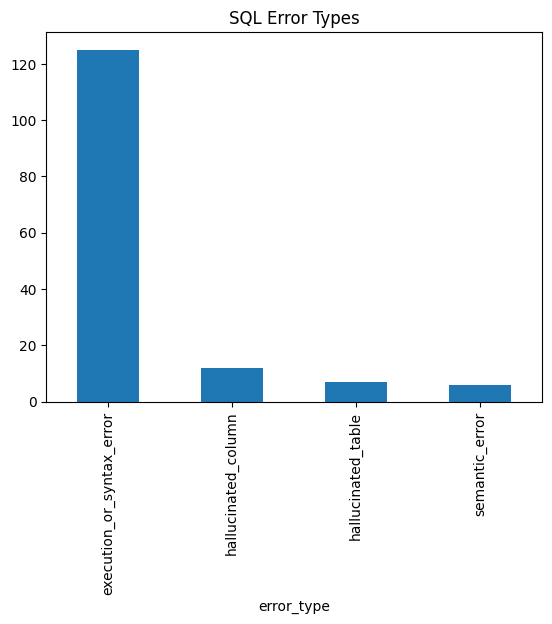

In [5]:
import json
import re
import pandas as pd

# Paths
BASE_PATH = "/content/drive/MyDrive/175/spider_data"
PRED_PATH = "/content/drive/MyDrive/175/outputs/gemma3-4bIT_output_clean.json"

# Load predictions
with open(PRED_PATH) as f:
    predictions = json.load(f)

df = pd.DataFrame(predictions)
print("Loaded predictions:", len(df))

# --- Helper Functions ---

def detect_syntax_error(pred_result):
    """Check if execution failed."""
    return pred_result is None

def extract_tables(sql):
    """Extract table names used in SQL."""
    return re.findall(r'FROM\s+(\w+)|JOIN\s+(\w+)', sql, re.IGNORECASE)

def clean_tables(matches):
    tables = []
    for m in matches:
        tables.extend([x for x in m if x])
    return tables

def hallucinated_table(pred_sql, gold_sql):
    pred_tables = set(clean_tables(extract_tables(pred_sql)))
    gold_tables = set(clean_tables(extract_tables(gold_sql)))
    return len(pred_tables - gold_tables) > 0

def extract_columns(sql):
    """Extract columns in format table.column."""
    return re.findall(r'\b\w+\.\w+\b', sql)

def hallucinated_column(pred_sql, gold_sql):
    pred_cols = set(extract_columns(pred_sql))
    gold_cols = set(extract_columns(gold_sql))
    return len(pred_cols - gold_cols) > 0

def aggregation_error(pred_sql, gold_sql):
    aggs = ["count(", "avg(", "sum(", "max(", "min("]
    gold_has_agg = any(x in gold_sql.lower() for x in aggs)
    pred_has_agg = any(x in pred_sql.lower() for x in aggs)
    return gold_has_agg and not pred_has_agg

def join_error(pred_sql, gold_sql):
    gold_has_join = "join" in gold_sql.lower()
    pred_has_join = "join" in pred_sql.lower()
    return gold_has_join and not pred_has_join

def categorize_error(row):
    if row["pred_result"] is None:
        return "execution_or_syntax_error"
    if hallucinated_table(row["predicted_sql"], row["gold_sql"]):
        return "hallucinated_table"
    if hallucinated_column(row["predicted_sql"], row["gold_sql"]):
        return "hallucinated_column"
    if aggregation_error(row["predicted_sql"], row["gold_sql"]):
        return "aggregation_error"
    if join_error(row["predicted_sql"], row["gold_sql"]):
        return "join_error"
    return "semantic_error"

# --- Execute SQL for all predictions ---

import sqlite3
from tqdm import tqdm

def execute_sql(db_id, sql):
    db_path = f"{BASE_PATH}/database/{db_id}/{db_id}.sqlite"
    try:
        conn = sqlite3.connect(db_path)
        cursor = conn.cursor()
        cursor.execute(sql)
        result = cursor.fetchall()
        conn.close()
        return result
    except:
        return None

# Add execution results to dataframe
df["gold_result"] = [execute_sql(row["db_id"], row["gold_sql"]) for idx, row in tqdm(df.iterrows(), total=len(df))]
df["pred_result"] = [execute_sql(row["db_id"], row["predicted_sql"]) for idx, row in tqdm(df.iterrows(), total=len(df))]

# Categorize errors
df["error_type"] = df.apply(categorize_error, axis=1)

# Error distribution
error_distribution = df["error_type"].value_counts(normalize=True) * 100
print(error_distribution)

# Save categorized errors
OUTPUT_PATH = "/content/drive/MyDrive/175/outputs/gemma2b_error_analysis.json"
df.to_json(OUTPUT_PATH, orient="records", indent=2)

# Optional: plot
import matplotlib.pyplot as plt
df["error_type"].value_counts().plot(kind="bar")
plt.title("SQL Error Types")
plt.show()